 # Librerias

 

In [1]:
import pandas as pd
import ast
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

 # Carga de datos 


In [2]:
df = pd.read_csv(r"..\..\Data\clean_data_16-03-2026.csv",parse_dates=['insert_date','first_review_date','last_review_date'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7537 entries, 0 to 7536
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   apartment_id                 7537 non-null   int64         
 1   name                         7534 non-null   object        
 2   description                  7537 non-null   object        
 3   host_id                      7537 non-null   int64         
 4   neighbourhood_name           7537 non-null   object        
 5   neighbourhood_district       7537 non-null   object        
 6   room_type                    7537 non-null   object        
 7   accommodates                 7537 non-null   int64         
 8   bathrooms                    7494 non-null   float64       
 9   bedrooms                     7499 non-null   float64       
 10  beds                         7530 non-null   float64       
 11  amenities_list               7537 non-null 

# Limpieza y Preprocesamiento de la variable "Amenities"

In [4]:

df['amenities_str'] = df['amenities_list'].astype(str)


# Quitamos llaves, corchetes y comillas
df['amenities_str'] = df['amenities_str'].str.replace(r'[\{\}\[\]\"]', '', regex=True)

# Arreglamos caracteres raros y espacios extraños
df['amenities_str'] = df['amenities_str'].str.replace('u2019', "'", regex=False)
df['amenities_str'] = df['amenities_str'].str.replace('\u00a0', ' ', regex=False)

# Unificamos los errores de escritura 
df['amenities_str'] = df['amenities_str'].str.replace(r"Children.s", "Children's", regex=True)
df['amenities_str'] = df['amenities_str'].str.replace(r"Pack .n Play", "Pack 'n Play", regex=True)
df['amenities_str'] = df['amenities_str'].str.replace('u2013', '-', regex=False)
df['amenities_str'] = df['amenities_str'].str.replace('u00a0', ' ', regex=False)

df['amenities_str'] = df['amenities_str'].str.replace('\u2013', '-', regex=False)


df['amenities_str'] = df['amenities_str'].str.replace('\u00a0', ' ', regex=False)


def extraer_y_filtrar(texto):
    if pd.isna(texto) or texto == 'nan':
        return []
    
    # Separamos por comas
    elementos = texto.split(',')
    lista_final = []
    
    for e in elementos:
        limpio = e.strip()
        # Si no está vacío y NO es un error de traducción o un sin contestar, lo guardamos
        if limpio and "translation missing" not in limpio.lower() and "(sin contestar)" not in limpio.lower():
            lista_final.append(limpio)
            
    return lista_final


# 3. APLICAMOS AL DATAFRAME PRINCIPAL 
df['amenities_final'] = df['amenities_str'].apply(extraer_y_filtrar)



todas_las_amenities = []
for lista in df['amenities_final']:
    todas_las_amenities.extend(lista)

lista_unica = sorted(list(set(todas_las_amenities)))

print(f"Se han encontrado {len(lista_unica)} amenities distintas ")

Se han encontrado 234 amenities distintas 


In [5]:
cat_accesibilidad = {
    'Accessible-height bed': 6,
    'Accessible-height toilet': 4,
    'Elevator': 4,
    'Elevator in building': 4,
    'Fixed grab bars for shower': 4,
    'Fixed grab bars for shower & toilet': 5,
    'Fixed grab bars for toilet': 4,
    'Flat': 10,
    'Flat path to front door': 7,
    'Flat path to guest entrance': 8,
    'Ground floor access': 4,
    'Mudroom': 8,
    'No stairs or steps to enter': 6,
    'Roll-in shower': 9,
    'Shower chair': 3,
    'Single level home': 7,
    'smooth pathway to front door': 8,
    'Step-free access': 6,
    'Step-free shower': 9,
    'Walk-in shower': 8,
    'Well-lit path to entrance': 7,
    'Wheelchair accessible': 5,
    'Wide clearance to bed': 8,
    'Wide clearance to shower': 7,
    'Wide clearance to shower & toilet': 6,
    'Wide doorway': 5,
    'Wide doorway to guest bathroom': 5,
    'Wide entrance': 9,
    'Wide entrance for guests': 8,
    'Wide entryway': 9,
    'Wide hallway clearance': 8,
    'Wide hallways': 8,
    'Bathtub with bath chair': 4

}

cat_wifi_oficina = {
    'Buzzer/wireless intercom': 6,
    'Dedicated workspace': 8,
    'Ethernet connection': 9,
    'Internet': 3,
    'Laptop-friendly workspace': 5,
    'Laptop friendly workspace': 6,
    'Pocket wifi': 6,
    'Printer': 7,
    'Wifi': 4,
    'Wifi - 100 Mbps': 8,
    'Wireless Internet': 4
}

cat_TV_clima = {
    '40 HDTV': 3,
    '43 HDTV with Netflix': 6,
    'Air conditioning': 7,
    'Amazon Echo': 7,
    'Bluetooth sound system': 8,
    'Cable TV': 4,
    'Ceiling fan': 4,
    'Central air conditioning': 9,
    'Central heating': 8,
    'DVD player': 1,
    'Game console': 9,
    'HBO GO': 7,
    'IKEA NEARBY Bluetooth sound system': 5,
    'Netflix': 7,
    'Portable fans': 2,
    'Smart TV': 7,
    'Sound system': 9,
    'TV': 3
}

cat_family_friendly = {
    'Baby bath': 4,
    'Baby monitor': 8,
    'Baby safety gates': 5,
    'Babysitter recommendations': 9,
    'Changing table': 7,
    "Children's books and toys": 6,
    "Children's dinnerware": 4,
    'Crib': 6,
    'Family/kid friendly': 3,
    'High chair': 5,
    'Outlet covers': 2,
    "Pack 'n Play/travel crib": 7,  
    'Pool toys': 7,
    'Stair gates': 5,
    'Table corner guards': 4  
}

cat_baños = {
    'Bath towel': 1,
    'Bathroom essentials': 1,
    'Bathtub': 4,
    'Bidet': 3,
    'Body soap': 2,
    'Conditioner': 2,
    'En suite bathroom': 10,
    'Hair dryer': 4,
    'Heated towel rack': 4,
    'Hot water': 1,
    'Rituals body soap': 6,
    'Rituals shampoo': 6,
    'Shampoo': 2,
    'Shower gel': 2,
    'Soaking tub': 9,
    'Toilet paper': 1,
    'Touchless faucets': 6,
    'Walk-in shower': 7,
    'toilet': 1
}

cat_cocina_equipada = {
    'Baking sheet': 2,
    'Bread maker': 6,
    'Breakfast table': 4,
    'Coffee maker': 4,
    'Convection oven': 7,
    'Cooking basics': 1,
    'Dining table': 4,
    'Dishes and silverware': 1,
    'Dishwasher': 8,
    'Double oven': 9,
    'Electric stove': 4,
    'Espresso machine': 6,
    'Freezer': 3,
    'Full kitchen': 7,
    'Gas oven': 4,
    'Hot water kettle': 3,
    'Kitchen': 8,
    'Kitchenette': 3,
    'Microwave': 4,
    'Mini fridge': 3,
    'Nespresso machine': 6,
    'Oven': 5,
    'Pour Over Coffee': 3,
    'Pour-over coffee': 3,
    'Refrigerator': 3,
    'Rice Maker': 4,
    'Stainless steel electric stove': 4,
    'Stainless steel oven': 5,
    'Stainless steel stove': 4,
    'Steam oven': 4,
    'Stove': 2,
    'Toaster': 3,
    'Warming drawer': 4,
    'Wine glasses': 2
}

cat_habitacion = {
    'Bed linens': 1,
    'Bedroom comforts': 1,
    'Clothing storage': 2,
    'Clothing storage: closet': 2,
    'Day bed': 7,
    'Extra pillows and blankets': 6,
    'Firm mattress': 2,
    'Hangers': 2,
    'Memory foam mattress': 7,
    'Murphy bed': 1,
    'Pillow-top mattress': 9,
    'Room-darkening shades': 5
}

cat_lujo = {
    'BBQ grill': 9,
    'Balcony': 7,
    'Barbecue utensils': 8,
    'Beach essentials': 6,
    'Beach view': 10,
    'Beachfront': 10,
    'Bluetooth sound system': 5,
    'Breakfast': 8,
    'Exercise equipment': 10,
    'Formal dining area': 8,
    'Game console': 8,
    'Garden or backyard': 10,
    'Gym': 10,
    'Hammock': 7,
    'Hot tub': 10,
    'IKEA NEARBY Bluetooth sound system': 5,
    'Lake access': 10,
    'Mountain view': 8,
    'Outdoor dining area': 9,
    'Outdoor furniture': 8,
    'Outdoor seating': 8,
    'Outdoor shower': 8,
    'Patio or balcony': 9,
    'Pool': 10,
    'Pool toys': 5,
    'Private living room': 6,
    'Rain shower': 9,
    'Shared garden or backyard': 5,
    'Shared outdoor pool': 7,
    'Shared pool': 7,
    'Ski in/Ski out': 10,
    'Ski-in/Ski-out': 10,
    'Sound system': 5,
    'Suitable for events': 9,
    'Sun loungers': 6,
    'Terrace': 8,
    'Waterfront': 10
}

cat_seguridad_logistica = {
    '24-hour check-in': 7,
    'Building staff': 9,
    'Buzzer/wireless intercom': 2,
    'Carbon monoxide alarm': 1,
    'Carbon monoxide detector': 1,
    'Doorman': 9,
    'Doorman Entry': 9,
    'EV charger': 9,
    'Fire extinguisher': 1,
    'Fireplace guards': 6,
    'First aid kit': 1,
    'Free driveway parking on premises - 1 space': 8,
    'Free parking on premises': 7,
    'Free parking on street': 6,
    'Free street parking': 6,
    'Front desk/doorperson': 9,
    'Host greets you': 2,
    'Keypad': 8,
    'Lock on bedroom door': 8,
    'Lockbox': 8,
    'Long term stays allowed': 5,
    'Luggage dropoff allowed': 7,
    'Mudroom': 7,
    'Paid parking garage off premises': 3,
    'Paid parking garage on premises': 3,
    'Paid parking off premises': 3,
    'Paid parking on premises': 3,
    'Private entrance': 10,
    'Safety card': 6,
    'Self Check-In': 8,
    'Self check-in': 8,
    'Smart lock': 8,
    'Smoke alarm': 1,
    'Smoke detector': 1,
    'Smoking allowed': 4
}

cat_limpieza_lavanderia = {
    
    'Cleaning products': 2,
    'Dryer': 9,
    'Drying rack for clothing': 3,
    'Iron': 5,
    'Laundromat nearby': 1,
    'Washer - In unit': 8
}

In [6]:
df_analisis=df[['room_type', 'price', 'accommodates', 'review_scores_location']].copy()

In [7]:

df_amenities = df[['room_type', 'amenities_list']].copy()


df_amenities['amenities_str'] = df_amenities['amenities_list'].astype(str)

# Quitamos llaves, corchetes y comillas
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r'[\{\}\[\]\"]', '', regex=True)

# Arreglamos caracteres raros y espacios extraños
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u2019', "'", regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('\u00a0', ' ', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r"Children.s", "Children's", regex=True)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace(r"Pack .n Play", "Pack 'n Play", regex=True)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u2013', '-', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('u00a0', ' ', regex=False)
df_amenities['amenities_str'] = df_amenities['amenities_str'].str.replace('\u2013', '-', regex=False)

def extraer_y_filtrar(texto):
    if pd.isna(texto) or texto == 'nan':
        return []
    
    elementos = texto.split(',')
    lista_final = []
    
    for e in elementos:
        limpio = e.strip()
        if limpio and "translation missing" not in limpio.lower() and "(sin contestar)" not in limpio.lower():
            lista_final.append(limpio)
            
    return lista_final

# Aplicamos tu función
df_amenities['amenities_final'] = df_amenities['amenities_str'].apply(extraer_y_filtrar)


def calcular_puntos(lista_del_piso, diccionario_categoria):
    puntos = 0
    for amenity in lista_del_piso:
        if amenity in diccionario_categoria:
            puntos += diccionario_categoria[amenity]
    return puntos

df_amenities['pts_accesibilidad'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_accesibilidad))
df_amenities['pts_wifi_oficina'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_wifi_oficina))
df_amenities['pts_tv_clima'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_TV_clima))
df_amenities['pts_family_friendly'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_family_friendly))
df_amenities['pts_banos'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_baños))
df_amenities['pts_cocina'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_cocina_equipada))
df_amenities['pts_habitacion'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_habitacion))
df_amenities['pts_lujo'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_lujo))
df_amenities['pts_seguridad'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_seguridad_logistica))
df_amenities['pts_lavanderia'] = df_amenities['amenities_final'].apply(lambda x: calcular_puntos(x, cat_limpieza_lavanderia))


columnas_puntos = [
    'pts_accesibilidad', 'pts_wifi_oficina', 'pts_tv_clima', 
    'pts_family_friendly', 'pts_banos', 'pts_cocina', 
    'pts_habitacion', 'pts_lujo', 'pts_seguridad', 'pts_lavanderia'
]

columnas_z_finales = []

for col in columnas_puntos:
    media = df_amenities.groupby('room_type')[col].transform('mean')
    std = df_amenities.groupby('room_type')[col].transform('std')
    
    nombre_z = f'z_{col}'
    df_amenities[nombre_z] = (df_amenities[col] - media) / (std + 0.0001)
    columnas_z_finales.append(nombre_z)

# Traspasamos SOLO los Z-scores a tu DataFrame original
df_analisis[columnas_z_finales] = df_amenities[columnas_z_finales]

# Comprobamos que ya no hay ceros
print(df_analisis[['room_type'] + columnas_z_finales].head())

         room_type  z_pts_accesibilidad  z_pts_wifi_oficina  z_pts_tv_clima  \
0     Private room            -0.173532            1.622359        1.258530   
1     Private room            -0.173532            1.622359        1.258530   
2  Entire home/apt             0.196359            1.611298        0.296152   
3     Private room            -0.173532            0.545464       -0.335386   
4     Private room             0.872898            0.007017       -1.018493   

   z_pts_family_friendly  z_pts_banos  z_pts_cocina  z_pts_habitacion  \
0              -0.348406     0.526540     -1.177342         -0.384146   
1              -0.348406     0.872193      1.424320          1.600832   
2               0.686327     1.826057     -0.013583          1.466433   
3              -0.348406     0.872193      1.124129         -0.384146   
4               6.369280     2.254808     -0.376831          1.600832   

   z_pts_lujo  z_pts_seguridad  z_pts_lavanderia  
0   -0.647986        -0.168962     

 Tratamiento y Transformación de "Amenities"

La columna amenities presentaba un reto analítico importante al contener listas de texto no estructuradas con cientos de equipamientos distintos. Para poder utilizar esta información en nuestros modelos predictivos, hemos diseñado el siguiente flujo de procesamiento:

Limpieza y Extracción:

Se realizó una limpieza general de las cadenas de texto para aislar y extraer una lista única con todas las amenities presentes en el conjunto de datos.

Categorización y Puntuación (Scoring): 

En lugar de crear más de 200 columnas binarias (una por cada equipamiento), decidimos agruparlas en 10 categorías de negocio (Seguridad, Lujo, Accesibilidad, etc.). A cada amenity se le asignó un peso o puntuación específica basándonos en el criterio del equipo de análisis.

Estandarización (Z-Scores): 

Tras sumar la puntuación de cada alojamiento en sus respectivas categorías, calculamos el Z-Score (puntuación típica). Este cálculo se realizó aislando por tipo de alojamiento (room_type), garantizando así que un piso entero se compare con la media de los pisos enteros, y una habitación privada con la media de las habitaciones.

Integración:

Finalmente, estas 10 nuevas métricas estandarizadas se incorporaron al DataFrame principal, sustituyendo a la variable original.

Consideraciones metodológicas y limitaciones:

Somos conscientes de que esta técnica introduce un grado de subjetividad en el análisis, ya que los pesos asignados a cada equipamiento responden a un criterio interno del equipo. Sin embargo, hemos optado por esta vía metodológica al considerarla la solución más eficiente para realizar una reducción de dimensionalidad drástica. De este modo, logramos transformar una columna textualmente inmanejable en variables numéricas estructuradas, capturando el valor de negocio subyacente sin saturar el modelo de Machine Learning con exceso de ruido.

In [8]:
df_analisis.head()

,room_type,price,accommodates,review_scores_location,z_pts_accesibilidad,z_pts_wifi_oficina,z_pts_tv_clima,z_pts_family_friendly,z_pts_banos,z_pts_cocina,z_pts_habitacion,z_pts_lujo,z_pts_seguridad,z_pts_lavanderia
0,Private room,400.0,2,100.0,-0.173532,1.622359,1.258530,-0.348406,0.526540,-1.177342,-0.384146,-0.647986,-0.168962,0.173870
1,Private room,170.0,1,80.0,-0.173532,1.622359,1.258530,-0.348406,0.872193,1.424320,1.600832,-0.647986,1.101843,0.173870
2,Entire home/apt,990.0,4,100.0,0.196359,1.611298,0.296152,0.686327,1.826057,-0.013583,1.466433,-0.801000,-0.083593,1.777892
3,Private room,400.0,2,100.0,-0.173532,0.545464,-0.335386,-0.348406,0.872193,1.124129,-0.384146,1.301048,0.169919,0.173870
4,Private room,900.0,5,100.0,0.872898,0.007017,-1.018493,6.369280,2.254808,-0.376831,1.600832,3.708679,1.440724,2.204519


 # Análisis / Visualizaciones 

In [9]:
df_analisis['z_amenities_global'] = df_analisis[columnas_z_finales].mean(axis=1)

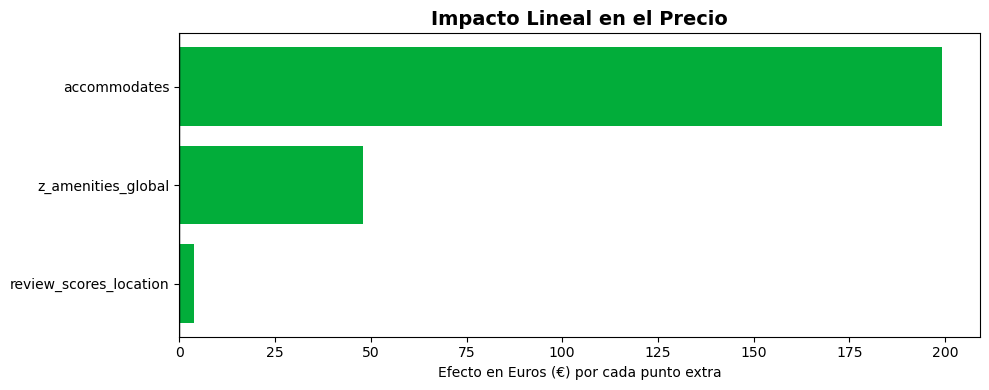

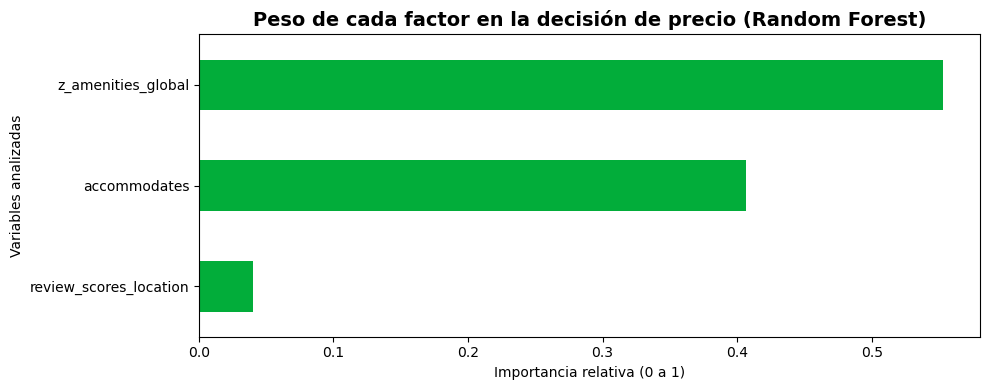


--- RESUMEN DE PESOS (RANDOM FOREST) ---


,Peso_Relativo,Porcentaje
z_amenities_global,0.552850,55.29%
accommodates,0.406752,40.68%
review_scores_location,0.040398,4.04%


In [10]:
# ==============================================================================
# MODELO GLOBAL: Comparativa de las 3 variables macro
# (Acomodación vs Localización vs Equipamiento Global)
# ==============================================================================
tres_variables = ['accommodates', 'review_scores_location', 'z_amenities_global']

# Asegúrate de que XX_train y yy_train están definidos con estas 3 variables
X_macro = df_analisis[tres_variables].dropna()
y_macro = df_analisis.loc[X_macro.index, 'price']


XX_train, XX_test, yy_train, yy_test = train_test_split(X_macro, y_macro, test_size=0.20, random_state=42)

# ------------------------------------------------------------------------------
# 1. VISIÓN DE NEGOCIO (Regresión Lineal - Impacto en Euros)
# ------------------------------------------------------------------------------


modelo_Lineal = LinearRegression()
modelo_Lineal.fit(XX_train, yy_train)

df_coefs = pd.DataFrame({'Variable': tres_variables, 'Coeficiente': modelo_Lineal.coef_})
df_coefs = df_coefs.sort_values(by='Coeficiente', ascending=True)

plt.figure(figsize=(10, 4))
colors = ['#A80000' if x < 0 else '#02AD3A' for x in df_coefs['Coeficiente']]
plt.barh(df_coefs['Variable'], df_coefs['Coeficiente'], color=colors)
plt.axvline(0, color='black', linestyle='-', linewidth=1)
plt.title('Impacto Lineal en el Precio', fontsize=14, fontweight='bold')
plt.xlabel('Efecto en Euros (€) por cada punto extra')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 2. VISIÓN ALGORÍTMICA (Random Forest - Importancia Relativa)
# ------------------------------------------------------------------------------
arbol = RandomForestRegressor(n_estimators=100, random_state=42)
arbol.fit(XX_train, yy_train)

importances = pd.Series(arbol.feature_importances_, index=tres_variables).sort_values(ascending=True)

plt.figure(figsize=(10, 4))
importances.plot(kind='barh', color='#02AD3A') 
plt.title('Peso de cada factor en la decisión de precio (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia relativa (0 a 1)')
plt.ylabel('Variables analizadas')
plt.tight_layout()
plt.show()

# Imprimimos la tabla resumen para ver el detalle
df_pesos = importances.to_frame(name='Peso_Relativo').sort_values(by='Peso_Relativo', ascending=False)
df_pesos['Porcentaje'] = (df_pesos['Peso_Relativo'] * 100).round(2).astype(str) + '%'
print("\n--- RESUMEN DE PESOS (RANDOM FOREST) ---")
display(df_pesos)

--- RENDIMIENTO DEL MODELO GLOBAL ---
Error Medio (MAE): 397.28 €
Precisión (R2 Score): 0.46
El modelo se equivoca, de media, un 52.19% respecto al precio real.


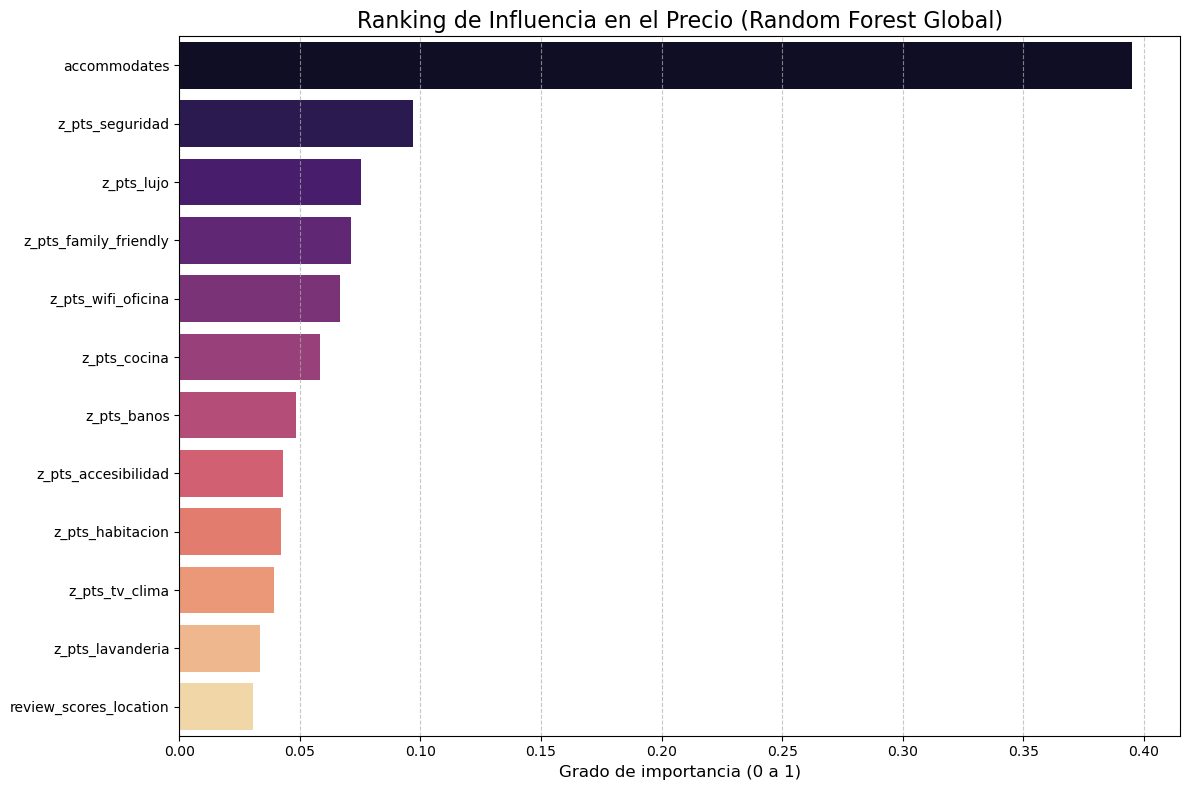

In [11]:

# 1. PREPARACIÓN DE DATOS (Modelo General)

# Seleccionamos solo las columnas de interés. 
# El 'room_type' no lo incluimos porque ya está "dentro" de los Z-scores.
columnas_estudio = ['price', 'accommodates', 'review_scores_location'] + columnas_z_finales
df_ml = df_analisis[columnas_estudio].copy().dropna()

X = df_ml.drop('price', axis=1)
y = df_ml['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# 2. ENTRENAMIENTO DEL MODELO GLOBAL

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# El comando .fit() es donde el bosque "estudia" las relaciones
modelo_rf.fit(X_train, y_train)


# 3. EVALUACIÓN DEL MODELO GLOBAL

# Hacemos el examen sorpresa con los datos que el modelo NO conoce (X_test)
predicciones = modelo_rf.predict(X_test)

# Calculamos el error medio (MAE) y el R2 (qué % de la variación del precio explica)
mae = mean_absolute_error(y_test, predicciones)
r2 = r2_score(y_test, predicciones)

print("--- RENDIMIENTO DEL MODELO GLOBAL ---")
print(f"Error Medio (MAE): {mae:.2f} €")
print(f"Precisión (R2 Score): {r2:.2f}")

# 1. Calcular el error en porcentaje (MAPE)
def mean_absolute_percentage_error(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, predicciones)
print(f"El modelo se equivoca, de media, un {mape:.2f}% respecto al precio real.")

# 4. EXTRACCIÓN DE RESULTADOS (Feature Importance)

# Le preguntamos al bosque: "¿Qué columnas te han servido más para decidir el precio?"
importancias = modelo_rf.feature_importances_
df_imp = pd.DataFrame({'Factor': X.columns, 'Importancia': importancias}).sort_values(by='Importancia', ascending=False)

# Dibujamos el ranking 
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Factor', hue='Factor', data=df_imp, palette='magma', legend=False)
plt.title('Ranking de Influencia en el Precio (Random Forest Global)', fontsize=16)
plt.xlabel('Grado de importancia (0 a 1)', fontsize=12)
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



El modelo global presenta un Error Medio Absoluto (MAE) de casi 400€ y se equivoca en un 52% al predecir los precios. Esto demuestra que el mercado de Airbnb es demasiado heterogéneo. Para reducir este error y obtener insights de negocio útiles, es obligatorio segmentar el análisis.

### 📍 Segmentación Geográfica: Análisis de Importancia por Ciudad

Tras comprobar las limitaciones predictivas de un modelo global, y en línea con el objetivo del proyecto de ir de lo macro a lo micro, procedemos a segmentar el análisis por mercado local. 

Para ello, hemos entrenado un modelo *Random Forest* independiente para cada una de las 8 ciudades. El objetivo de este gráfico de dispersión (Bubble Chart) es mapear visualmente la "Feature Importance" (el peso que el algoritmo le otorga a cada variable para predecir el precio) en cada mercado. Esto nos permite descubrir si un usuario de Airbnb valora lo mismo al buscar piso en la costa balear que en una gran capital.

In [12]:
df_analisis_city = df_analisis

In [13]:
# 1. Traemos la ciudad del df original usando el índice para que coincidan perfectamente
df_analisis_city['city'] = df['city']

In [14]:


# 1. Definimos las ciudades y las variables
ciudades = df_analisis_city['city'].unique()
variables_amenities = [
    'accommodates', 'review_scores_location', 'z_pts_accesibilidad', 
    'z_pts_wifi_oficina', 'z_pts_tv_clima', 'z_pts_family_friendly', 
    'z_pts_banos', 'z_pts_cocina', 'z_pts_habitacion', 
    'z_pts_lujo', 'z_pts_seguridad', 'z_pts_lavanderia'
]

resultados_lista = []

# 2. Bucle para calcular importancia por ciudad
for ciudad in ciudades:
    df_c = df_analisis_city[df_analisis_city['city'] == ciudad].dropna(subset=variables_amenities + ['price'])
    
    if len(df_c) > 30: # Filtro mínimo de datos para que el modelo sea fiable
        X = df_c[variables_amenities]
        y = df_c['price']
        
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        # Guardamos los resultados
        for var, imp in zip(variables_amenities, rf.feature_importances_):
            resultados_lista.append({
                'Ciudad': ciudad,
                'Categoria': var.replace('z_pts_', '').upper(),
                'Importancia': imp
            })

# 3. Convertimos a DataFrame
df_burbujas = pd.DataFrame(resultados_lista)
df_burbujas.to_csv('categorias_ciudades.csv')
print(df_burbujas)

     Ciudad               Categoria  Importancia
0    Malaga            ACCOMMODATES     0.264088
1    Malaga  REVIEW_SCORES_LOCATION     0.026174
2    Malaga           ACCESIBILIDAD     0.040981
3    Malaga            WIFI_OFICINA     0.063087
4    Malaga                TV_CLIMA     0.170424
..      ...                     ...          ...
91  Menorca                  COCINA     0.024653
92  Menorca              HABITACION     0.033256
93  Menorca                    LUJO     0.028452
94  Menorca               SEGURIDAD     0.132031
95  Menorca              LAVANDERIA     0.021779

[96 rows x 3 columns]


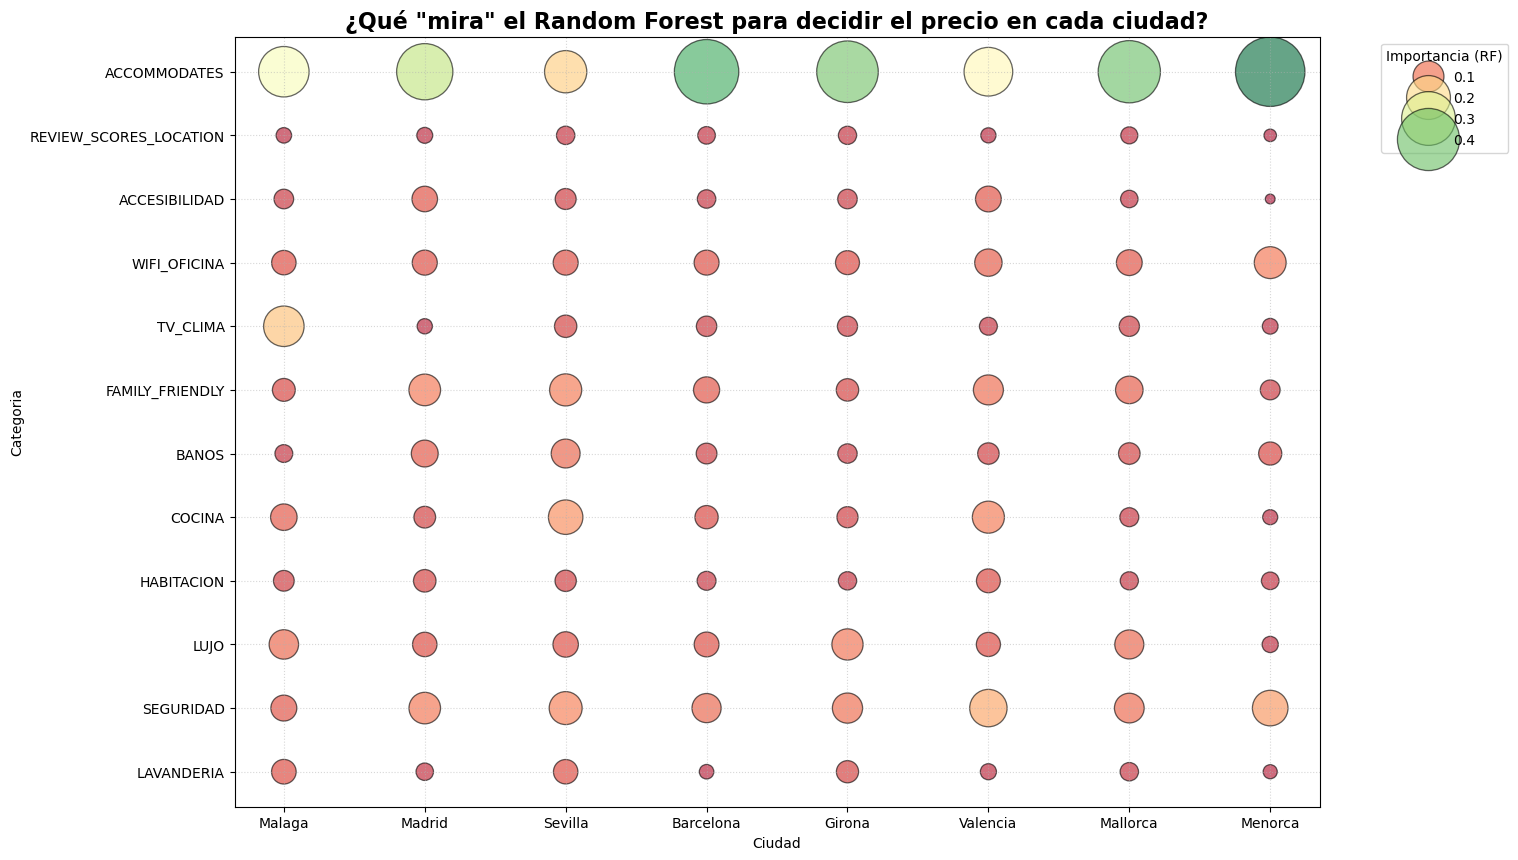

In [15]:


plt.figure(figsize=(14, 10))

# El tamaño (size) de la burbuja es el 'Peso_RF'
sns.scatterplot(
    data=df_burbujas,
    x='Ciudad',
    y='Categoria',
    size='Importancia',      # <--- AQUÍ entra el resultado del Random Forest
    hue='Importancia',      # El color también cambia según la importancia
    palette='RdYlGn',   # De Rojo (NOK) a Verde (OK)
    sizes=(50, 2500),   # Ajustamos el rango de tamaños para que sea visual
    alpha=0.6,
    edgecolor='black'
)

plt.title('¿Qué "mira" el Random Forest para decidir el precio en cada ciudad?', fontsize=16, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(title='Importancia (RF)', bbox_to_anchor=(1.05, 1))
plt.show()

**Conclusiones clave del Análisis Local:**

*   **El reinado absoluto de la Capacidad (`ACCOMMODATES`):** Es el factor dominante en todos los mercados, pero su peso es colosal en destinos de turismo vacacional puro como **Menorca, Mallorca, Girona y Barcelona** (burbujas verdes de mayor tamaño). En estos destinos, meter a una persona más define radicalmente el precio.
*   **La particularidad climática de Málaga:** Es el único mercado donde la variable `TV_CLIMA` destaca de forma tan evidente (burbuja amarilla grande). En el sur, factores como el aire acondicionado dejan de ser un extra para convertirse en un factor predictivo decisivo.
*   **Equipamientos transversales:** Las categorías de `SEGURIDAD` y `LUJO` mantienen un peso relativo muy constante en casi todas las ciudades. Son los "extras" más seguros a la hora de aportar valor a un inmueble, independientemente de dónde esté.
*   **La nota de ubicación pierde peso:** Sorprendentemente, el algoritmo casi ignora la variable `REVIEW_SCORES_LOCATION` en todas las ciudades (burbujas muy pequeñas). Esto sugiere que, una vez dentro de la ciudad, el cliente paga más por las comodidades y el tamaño del inmueble que por ligeras variaciones en la puntuación de la zona.

###  Segmentación por Poder Adquisitivo: El impacto de las Franjas de Precio

Tras analizar el comportamiento geográfico, abordamos la última gran dimensión de nuestro análisis: el poder adquisitivo del cliente. 

El objetivo de esta fase es demostrar empíricamente una hipótesis de negocio: las reglas que definen el precio cambian radicalmente según el tipo de producto que ofrecemos. Para comprobarlo, hemos dividido el mercado global en tres *terciles* (Segmento Low Cost, Segmento Standard y Segmento Premium). Entrenando un modelo independiente para cada estrato, podemos comparar visualmente cómo muta la importancia de cada variable a medida que el cliente está dispuesto a pagar más.

Segmentos: Bajo (hasta 550.00€), Medio (hasta 1000.00€), Alto (más de 1000.00€)


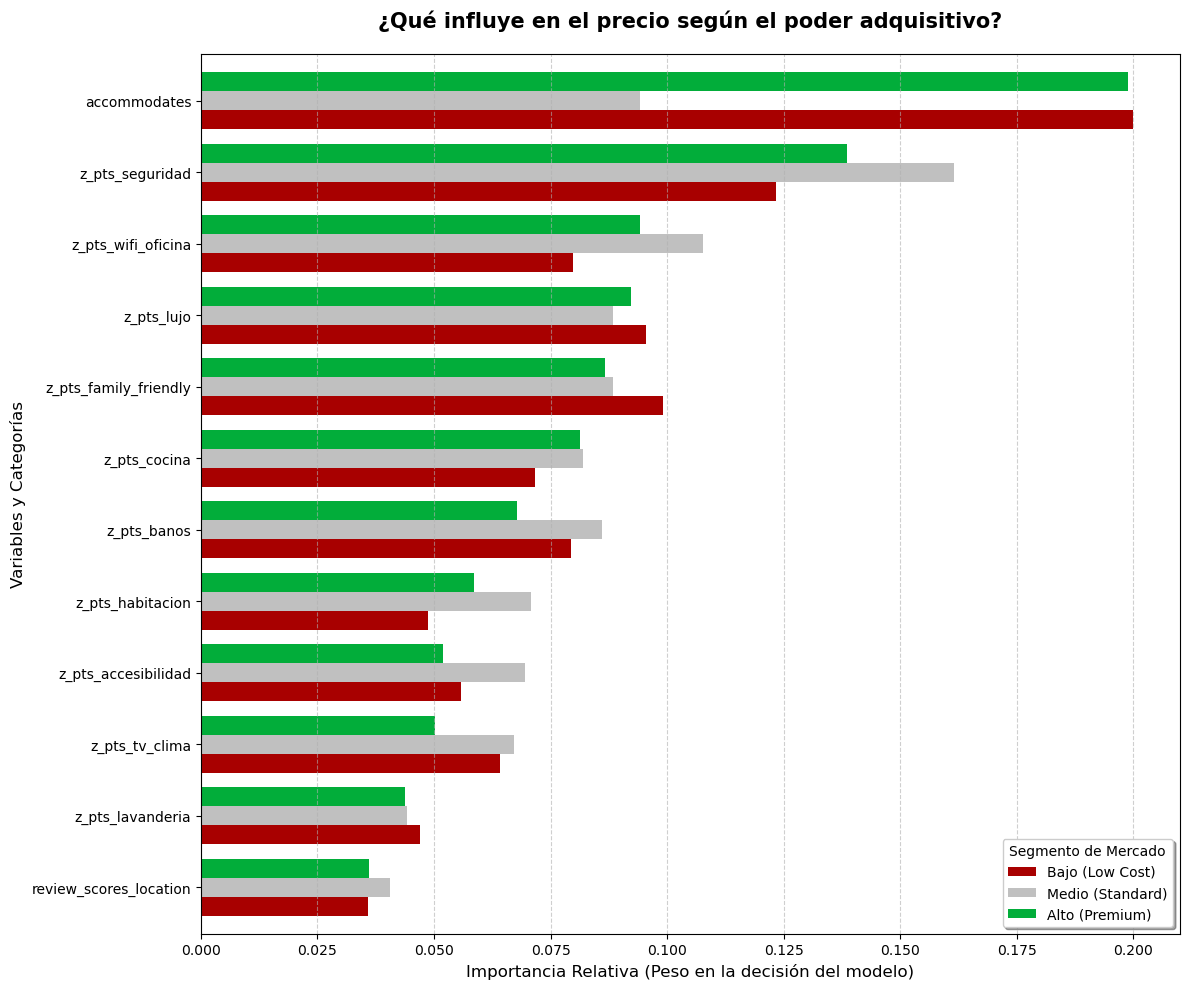

In [16]:
# ==============================================================================
# SEGMENTACIÓN POR PRECIO: ¿Qué importa en cada franja del mercado?
# ==============================================================================
# 1. Calculamos los cortes de precio (terciles)
cortes = df_analisis['price'].quantile([0.33, 0.66]).values
print(f"Segmentos: Bajo (hasta {cortes[0]:.2f}€), Medio (hasta {cortes[1]:.2f}€), Alto (más de {cortes[1]:.2f}€)")

# 2. Definimos las variables a estudiar
columnas_estudio = [
    'accommodates', 'review_scores_location', 'z_pts_accesibilidad', 
    'z_pts_wifi_oficina', 'z_pts_tv_clima', 'z_pts_family_friendly', 
    'z_pts_banos', 'z_pts_cocina', 'z_pts_habitacion', 
    'z_pts_lujo', 'z_pts_seguridad', 'z_pts_lavanderia'
]

# 3. Función para entrenar un modelo rápido y devolver las importancias
def obtener_importancias_segmento(data):
    # Limpiamos datos solo para este subconjunto
    df_temp = data.dropna(subset=columnas_estudio + ['price'])
    X_seg = df_temp[columnas_estudio]
    y_seg = df_temp['price']
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_seg, y_seg)
    return pd.Series(rf.feature_importances_, index=X_seg.columns)

# 4. Aplicamos el modelo a cada segmento de precio
bajo = df_analisis[df_analisis['price'] <= cortes[0]]
medio = df_analisis[(df_analisis['price'] > cortes[0]) & (df_analisis['price'] <= cortes[1])]
alto = df_analisis[df_analisis['price'] > cortes[1]]

imp_bajo = obtener_importancias_segmento(bajo)
imp_medio = obtener_importancias_segmento(medio)
imp_alto = obtener_importancias_segmento(alto)

# 5. Consolidamos resultados para graficar
df_imp_grafico = pd.DataFrame({
    'Bajo (Low Cost)': imp_bajo,
    'Medio (Standard)': imp_medio,
    'Alto (Premium)': imp_alto
})

# Ordenamos el DataFrame por la importancia en el segmento Alto para que quede visualmente escalonado
df_imp_grafico = df_imp_grafico.sort_values(by='Alto (Premium)', ascending=True)

# 6. Generar el gráfico comparativo horizontal
colores_segmentos = ['#A80000', '#C0C0C0', '#02AD3A'] # Rojo, Gris, Verde

ax = df_imp_grafico.plot(kind='barh', figsize=(12, 10), color=colores_segmentos, width=0.8)

# Configuración estética
plt.title('¿Qué influye en el precio según el poder adquisitivo?', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Importancia Relativa (Peso en la decisión del modelo)', fontsize=12)
plt.ylabel('Variables y Categorías', fontsize=12)

# Colocamos la leyenda indicando los segmentos de precio
plt.legend(title="Segmento de Mercado", labels=['Bajo (Low Cost)', 'Medio (Standard)', 'Alto (Premium)'], 
           loc='lower right', frameon=True, shadow=True)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Conclusiones: El comportamiento según el presupuesto
Al analizar cómo cambia el peso de las variables según el poder adquisitivo, extraemos insights muy valiosos para el negocio:

La capacidad manda en los extremos: La variable accommodates reina indiscutiblemente, pero curiosamente tiene un impacto brutal tanto en el mercado Low Cost (barra roja, donde el cliente busca exprimir al máximo el coste por cama) como en el Premium (barra verde, donde los grandes chalets o villas de alta ocupación disparan los precios).

Seguridad y Conectividad marcan el salto de gama: Pasar del mercado económico al medio o alto exige garantías. Vemos claramente cómo z_pts_seguridad y z_pts_wifi_oficina (barras grises y verdes) cobran muchísima más fuerza algorítmica a medida que sube el ticket medio del alojamiento.

El cliente Low Cost es más familiar: Curiosamente, la categoría z_pts_family_friendly tiene su mayor impacto relativo en el segmento de bajo coste (barra roja más larga), indicando que las familias o grupos que viajan con presupuesto ajustado miran con lupa este tipo de equipamientos.

La puntuación de la zona no es decisiva para el precio: Se confirma la tendencia general; la variable review_scores_location es la que menos ayuda al modelo a fijar el precio, manteniéndose a la cola independientemente de lo abultada que sea la cartera del cliente.

###  El Análisis Definitivo: Intersección Geográfica y de Poder Adquisitivo

Llegamos a la culminación de nuestro modelo de análisis. Hasta ahora hemos comprobado que, a nivel global, el peso de los equipamientos sube a medida que aumenta el poder adquisitivo del cliente. Sin embargo, nuestro objetivo como analistas es proporcionar herramientas de decisión a nivel hiperlocal.

¿Se comporta igual el segmento "Premium" en un mercado de interior urbano como Sevilla que en un mercado insular estacional como Mallorca?

Para responder a esto, hemos diseñado un "Bucle Maestro" que entrena un total de **24 modelos Random Forest independientes** (3 franjas de precio $\times$ 8 ciudades). Posteriormente, hemos reagrupado las importancias algorítmicas en las 3 grandes variables de negocio: Capacidad, Equipamientos y Zona. 

El siguiente gráfico de paneles múltiples (Small Multiples) visualiza la evolución del peso de estas variables cruzando, por primera vez, geografía y nivel adquisitivo.

Columnas listas para el análisis: ['room_type', 'price', 'accommodates', 'review_scores_location', 'z_pts_accesibilidad', 'z_pts_wifi_oficina', 'z_pts_tv_clima', 'z_pts_family_friendly', 'z_pts_banos', 'z_pts_cocina', 'z_pts_habitacion', 'z_pts_lujo', 'z_pts_seguridad', 'z_pts_lavanderia', 'z_amenities_global', 'city']
Total de pisos listos: 5949


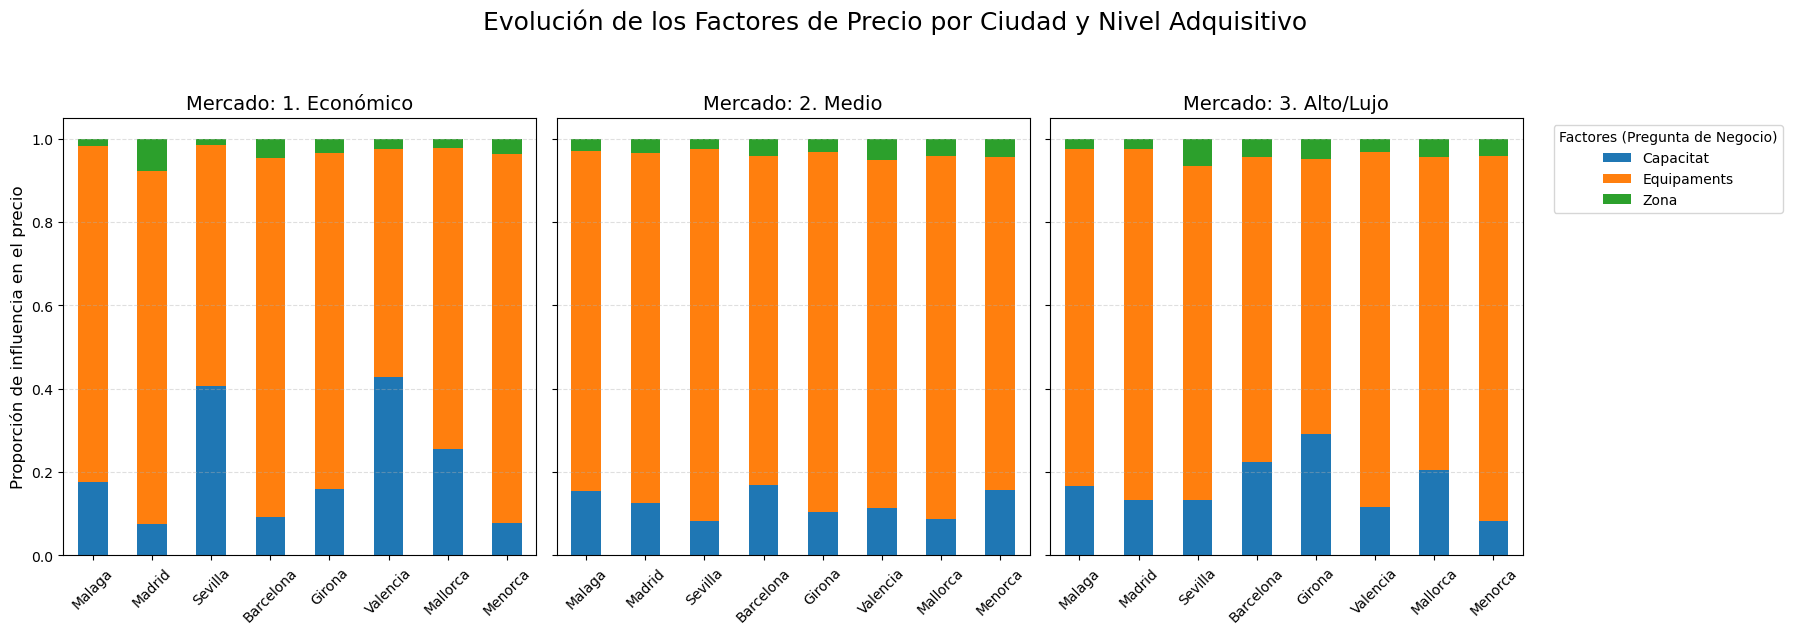

In [17]:





# Partimos de tu df_analisis que sabemos al 100% que ya tiene los Z-Scores listos
df_analisis_2 = df_analisis.copy()

# Le añadimos la columna 'city' rescatándola de tu dataset original
# Pandas asignará la ciudad correcta a cada piso usando el número de índice automáticamente
df_analisis_2['city'] = df['city']

# Limpiamos los nulos por si algún piso se ha quedado "huérfano" de ciudad
df_analisis_2 = df_analisis_2.dropna()

# Comprobación rápida para quedarnos tranquilos
print(f"Columnas listas para el análisis: {df_analisis_2.columns.tolist()}")
print(f"Total de pisos listos: {len(df_analisis_2)}")

# ==============================================================================
# BUCLE MAESTRO: CIUDADES x FRANJAS DE PRECIO
# ==============================================================================
ciudades = df_analisis_2['city'].unique()
resultados_totales = []

for ciudad in ciudades:
    # Filtramos solo los pisos de esta ciudad
    df_ciudad = df_analisis_2[df_analisis_2['city'] == ciudad].copy()
    
    # Filtro de seguridad por si hay pocos datos
    if len(df_ciudad) < 90: 
        print(f"Aviso: {ciudad} tiene muy pocos datos limpios, se omite.")
        continue
        
    # Calculamos los cortes (terciles)
    cortes = df_ciudad['price'].quantile([0.33, 0.66]).values
    
    franjas = {
        '1. Económico': df_ciudad[df_ciudad['price'] <= cortes[0]],
        '2. Medio': df_ciudad[(df_ciudad['price'] > cortes[0]) & (df_ciudad['price'] <= cortes[1])],
        '3. Alto/Lujo': df_ciudad[df_ciudad['price'] > cortes[1]]
    }
    
    # Entrenamos el modelo para cada franja
    for nombre_franja, df_franja in franjas.items():
        if len(df_franja) < 30: 
            continue
            
     # LA SOLUCIÓN DEFINITIVA: Le pasamos SOLO las columnas del estudio
        columnas_estudio_final = ['accommodates', 'review_scores_location'] + columnas_z_finales
        X_f = df_franja[columnas_estudio_final]
        y_f = df_franja['price']
        
        # Modelo 
        modelo_f = RandomForestRegressor(n_estimators=150, random_state=42)
        modelo_f.fit(X_f, y_f)
        
        # Extraemos importancias
        imp = pd.Series(modelo_f.feature_importances_, index=X_f.columns)
        
        # Agrupamos en las 3 cajas
        capacidad = imp.get('accommodates', 0)
        zona = imp.get('review_scores_location', 0)
        equipaments = imp[columnas_z_finales].sum()
        
        resultados_totales.append({
            'Ciudad': ciudad,
            'Franja': nombre_franja,
            'Capacitat': capacidad,
            'Zona': zona,
            'Equipaments': equipaments
        })

df_resultados = pd.DataFrame(resultados_totales)

# ==============================================================================
# VISUALIZACIÓN: SMALL MULTIPLES (3 PANELES)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
titulos_franjas = ['1. Económico', '2. Medio', '3. Alto/Lujo']

for i, franja in enumerate(titulos_franjas):
    data_plot = df_resultados[df_resultados['Franja'] == franja].set_index('Ciudad')
    
    if data_plot.empty:
        continue
        
    data_plot = data_plot[['Capacitat', 'Equipaments', 'Zona']] 
    
    data_plot.plot(kind='bar', stacked=True, ax=axes[i], legend=(i==2), 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    
    axes[i].set_title(f'Mercado: {franja}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)
    axes[i].tick_params(axis='x', rotation=45) 

    if i == 0:
        axes[i].set_ylabel('Proporción de influencia en el precio', fontsize=12)

if len(axes[2].get_legend_handles_labels()[0]) > 0:
    axes[2].legend(title="Factores (Pregunta de Negocio)", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle('Evolución de los Factores de Precio por Ciudad y Nivel Adquisitivo', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [18]:

# ==============================================================================
# EVALUACIÓN DE LOS 24 MODELOS SEGMENTADOS
# ==============================================================================
resultados_metricas = []

for ciudad in ciudades:
    df_ciudad = df_analisis_2[df_analisis_2['city'] == ciudad].copy()
    
    if len(df_ciudad) < 90: 
        continue
        
    cortes = df_ciudad['price'].quantile([0.33, 0.66]).values
    
    franjas = {
        '1. Económico': df_ciudad[df_ciudad['price'] <= cortes[0]],
        '2. Medio': df_ciudad[(df_ciudad['price'] > cortes[0]) & (df_ciudad['price'] <= cortes[1])],
        '3. Alto/Lujo': df_ciudad[df_ciudad['price'] > cortes[1]]
    }
    
    for nombre_franja, df_franja in franjas.items():
        # Aseguramos que haya un mínimo de datos para poder dividir en Train/Test
        if len(df_franja) < 40: 
            continue
            
        # Usamos exactamente las mismas columnas que en el gráfico final
        columnas_estudio_final = ['accommodates', 'review_scores_location'] + columnas_z_finales
        X_eval = df_franja[columnas_estudio_final]
        y_eval = df_franja['price']
        
        # Dividimos los datos: 80% estudiar, 20% examinar
        X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_eval, y_eval, test_size=0.20, random_state=42)
        
        modelo_eval = RandomForestRegressor(n_estimators=100, random_state=42)
        modelo_eval.fit(X_train_e, y_train_e)
        
        # Examen sorpresa
        predicciones = modelo_eval.predict(X_test_e)
        
        mae = mean_absolute_error(y_test_e, predicciones)
        r2 = r2_score(y_test_e, predicciones)
        
        resultados_metricas.append({
            'Ciudad': ciudad,
            'Segmento': nombre_franja,
            'Muestra (N)': len(df_franja),
            'Precisión (R2)': round(r2, 2),
            'Error Medio (€)': round(mae, 2)
        })

# Creamos la tabla y la mostramos
df_metricas = pd.DataFrame(resultados_metricas)

print("--- RENDIMIENTO DE LOS MODELOS SEGMENTADOS ---")
# Mostramos la tabla formateada. Si usas Jupyter, display() queda mucho más elegante que print()
display(df_metricas)

# Calculamos la media de error de todos los modelos juntos para comparar con el modelo global del principio
error_medio_total = df_metricas['Error Medio (€)'].mean()
print(f"\n✅ ERROR MEDIO GLOBAL SEGMENTADO: {error_medio_total:.2f} €")

--- RENDIMIENTO DE LOS MODELOS SEGMENTADOS ---


,Ciudad,Segmento,Muestra (N),Precisión (R2),Error Medio (€)
0,Malaga,1. Económico,117,0.44,59.20
1,Malaga,2. Medio,119,-0.03,58.49
2,Malaga,3. Alto/Lujo,116,-0.12,516.47
3,Madrid,1. Económico,453,0.38,61.68
4,Madrid,2. Medio,456,0.11,78.02
5,Madrid,3. Alto/Lujo,449,0.04,396.77
6,Sevilla,1. Económico,123,0.47,67.40
7,Sevilla,2. Medio,120,-0.73,80.92
8,Sevilla,3. Alto/Lujo,121,0.12,700.42
9,Barcelona,1. Económico,596,0.01,59.77



✅ ERROR MEDIO GLOBAL SEGMENTADO: 273.86 €


Conclusiones de la Evaluación de Modelos (Métricas de Rendimiento)El análisis de las métricas de error (MAE) y precisión ($R^2$) de los 24 micromodelos nos revela insights críticos sobre la predictibilidad del mercado inmobiliario turístico:

Éxito predictivo en el Segmento Económico:

 La segmentación ha sido un éxito rotundo para el mercado base. En las grandes capitales (Madrid, Barcelona, Sevilla, Málaga), el Error Medio Absoluto (MAE) en la franja económica se ha desplomado a unos 60€, con los valores de $R^2$ más altos del estudio (rozando el 0.50). Esto confirma que las reglas de precio en el mercado estándar están fuertemente estandarizadas y nuestro modelo las captura con éxito.
 
 El techo algorítmico del Segmento Premium:
 
  Observamos que en la franja "Alto/Lujo", el error medio se dispara (entre 400€ y 800€) y el $R^2$ cae. Esto responde a la propia naturaleza del mercado de lujo, que no tiene un "techo" de precio y presenta una varianza extrema (outliers). Además, en este segmento entran en juego variables intangibles que nuestro dataset no recoge (vistas exclusivas a monumentos, diseño de interiores de autor, servicios de chef privado, etc.), limitando la capacidad del algoritmo para afinar el precio exacto.
  
  El valor de negocio de la segmentación:
  
   Tener modelos con $R^2$ negativo en algunas franjas intermedias indica que la dispersión de precios es tan estrecha y los equipamientos tan similares que el algoritmo no encuentra un patrón matemático diferencial. La gran victoria de esta segmentación es haber logrado aislar el "ruido" y la volatilidad extrema del mercado de lujo; si hubiéramos mantenido un modelo global, este caos habría contaminado las predicciones del mercado económico, haciéndolo inútil para la toma de decisiones.

###  Conclusiones Generales


Al aislar el poder predictivo del algoritmo exclusivamente en nuestras tres variables de negocio (Capacidad, Equipamientos y Zona), extraemos insights definitivos sobre el comportamiento del mercado de Airbnb en España:

El reinado absoluto de los Equipamientos (Amenities): La franja naranja domina abrumadoramente en los tres paneles y en casi todas las ciudades. Esto demuestra que, a la hora de predecir o fijar un precio competitivo, lo que contiene la vivienda (lujo, seguridad, comodidades, tecnología) tiene muchísimo más peso que el tamaño de la misma.

La Capacidad es una palanca local y específica: Aunque los equipamientos mandan, la variable Capacitat (franja azul) tiene picos de importancia muy notables en mercados concretos. Destaca su peso en el segmento Económico de Sevilla y Valencia (donde maximizar camas es clave para ajustar precios bajos), y curiosamente gana tracción en el segmento Premium de Girona y Barcelona (donde las grandes villas o pisos de alta capacidad sí mueven la aguja del precio en la gama alta).

La Zona no es un diferenciador de precio: La barra verde (Zona) es residual de forma unánime. Esto corrobora nuestra hipótesis anterior: una buena nota de ubicación es una barrera de entrada básica (un "desde"), pero no es la palanca algorítmica que te permite escalar el precio de tu alojamiento frente a la competencia.